# Tutorial 08 — bcc iron: collinear spin-polarized Wannierisation

The waw-native reimagining of Wannier90 tutorial 8 — the first **spin-polarized** tutorial. Unlike notebooks 17/18 (noncollinear + spin-orbit, spinor MLWFs), this is an ordinary **collinear** magnetic calculation: QE's `nspin=2` solves one exchange-split SCF, and the up and down spin channels are each Wannierised **independently** as ordinary (non-spinor) entangled problems — 9 Fe $s;p;d$ MLWFs per channel, 18 total, no new waw machinery needed.

**One new `qe.py` wrinkle**: `pw2wannier90` needs telling which spin channel to write via `spin_component='up'/'down'` — run once per channel (with a distinct seedname so the SCF/overlaps don't collide), reading the *same* (spin-independent) neighbour topology each time.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and converged DFT (one run per spin channel)
Same bcc Fe cell as notebooks 17/18 ($a=2.8699$ Å), but plain collinear `nspin=2` (no `noncolin`/`lspinorb`). 14 bands per channel (4 semicore 3$s$3$p$ excluded, buffer above that), SCDM `erfc` (same $\mu,\sigma$ as the SOC notebooks — the target $d+s$ manifold sits at the same energies regardless of spin treatment).

In [2]:
from ase.build import bulk

atoms = bulk('Fe', 'bcc', a=2.8699)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'fe_collinear'
COLLIN = dict(nspin=2, occupations='smearing', smearing='cold', degauss=0.02)
COLLIN['starting_magnetization(1)'] = 0.4

overlaps, results = {}, {}
for spin, seed in (('up', 'fe_up'), ('down', 'fe_dn')):
    ov = qe.generate_overlaps(
        atoms, MP_GRID, WORK, seed,
        ecutwfc=60, scf_kpts=(8, 8, 8), nbnd=18, num_wann=9,
        exclude_bands=list(range(1, 5)),
        scdm_entanglement='erfc', scdm_mu=25.0, scdm_sigma=5.0,
        system_extra=COLLIN, pseudopotentials={'Fe': 'Fe.upf'},
        pseudo_dir=PSEUDO_DIR, ncores=NCORES, spin_component=spin,
        rerun_scf=False,      # reuse a completed SCF in runs/fe_collinear/ if present
    )
    overlaps[spin] = ov
    print(seed, 'overlap shapes:', {k: np.shape(v) for k, v in ov.items()
                                     if k in ('mmn', 'amn', 'eig')})

fe_up overlap shapes: {'mmn': (64, 12, 14, 14), 'amn': (64, 14, 9), 'eig': (64, 14)}


fe_dn overlap shapes: {'mmn': (64, 12, 14, 14), 'amn': (64, 14, 9), 'eig': (64, 14)}


### 2. Wannierise each channel independently
9 disentangled Fe $s;p;d$ MLWFs per spin, frozen window to 30 eV (occupied $d$ manifold), outer window to 70 eV — the same windows Wannier90 tutorial 8 uses.

In [3]:
for spin in ('up', 'down'):
    ov = overlaps[spin]
    result = wannierize(
        atoms, MP_GRID, ov['kpts'],
        mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
        nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
        nw=9, outer_window=(-1e3, 70.0), frozen_window=(-1e3, 30.0),
        n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
    )
    results[spin] = result
    omega_I = result.dis.omega_i * BOHR_TO_ANG**2
    omega = result.omega_final * BOHR_TO_ANG**2
    ref = {'up': (4.7486, 6.5245), 'down': (4.6235, 6.3387)}[spin]
    print(f'{spin:5s}  Omega_I={omega_I:.4f} (w90 {ref[0]})  '
          f'Omega_total={omega:.4f} (w90 {ref[1]}) Ang^2')

up     Omega_I=5.1600 (w90 4.7486)  Omega_total=5.6619 (w90 6.5245) Ang^2


down   Omega_I=5.2558 (w90 4.6235)  Omega_total=5.8232 (w90 6.3387) Ang^2


The two channels differ — the spin-split Fe $d$-bands give slightly different Wannier spreads for up vs. down, exactly as in the real spin-polarized calculation. Each channel independently reaches close to Wannier90's own $\Omega_I$.

### 3. Spin-resolved band structure
ASE's standard bcc path, both channels against a single non-self-consistent
`nspin=2` bands run (points). Plotting them together shows the exchange
splitting directly, and it is the case where one window can be comfortable for
the majority manifold while cutting through the minority one — so each channel
is checked against the bands it was actually fitted to.

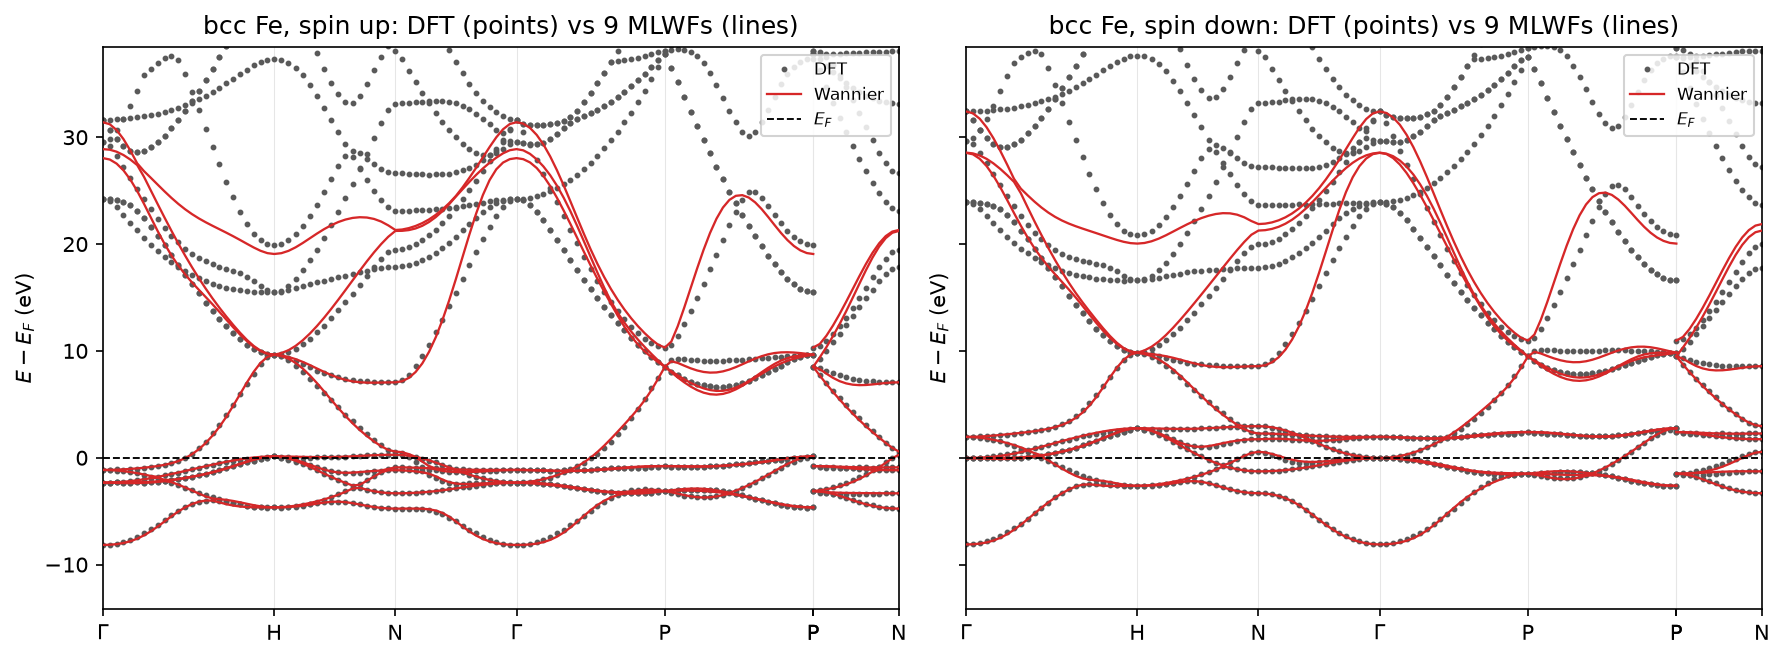

spin up  : on the Wannier mesh max 6317.077 meV, rms 936.494 meV over 576 states
spin down: on the Wannier mesh max 6426.751 meV, rms 908.070 meV over 576 states


In [4]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = overlaps['up']['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
try:                        # nspin=2 -> (2, nk, nbnd): [0] majority, [1] minority
    dft_bands = bands_along_path(WORK, 'fe_up', bp.kpts, ncores=NCORES, nspin=2)
except FileNotFoundError as exc:
    dft_bands = None
    print(exc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150, sharey=True)
for j, spin in enumerate(('up', 'down')):
    bands = interpolate_bands(results[spin].hr, bp.kpts) * HARTREE_TO_EV
    ref = dft_bands[j] if dft_bands is not None else np.full_like(bands, np.nan)
    plot_wannierization_windows(
        axes[j], xcoords, ref, bands, fermi_energy=E_F, xticks=xspecial,
        xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
    axes[j].set_title(f'bcc Fe, spin {spin}: DFT (points) vs 9 MLWFs (lines)')
plt.tight_layout(); plt.show()

for spin in ('up', 'down'):
    fid = mesh_fidelity(results[spin].hr, overlaps[spin]['kpts'],
                        overlaps[spin]['eig'], fermi_ev=E_F)
    print(f"spin {spin:4s}: on the Wannier mesh max {fid['max']:.3f} meV, "
          f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


The exchange splitting between the blue (up) and red (down) bands is the ferromagnetic Stoner splitting responsible for Fe's magnetic moment.

**Takeaway.** Collinear spin-polarized Wannierisation is just two ordinary entangled Wannierisations — the only new capability needed was `pw2wannier90`'s `spin_component` keyword in `qe.py`, one line in the pw2wannier90 namelist.